## Kredt — Exploratory Data Analysis

### EDA OBJECTIVE:
Assess the quality, distribution, and predictive relevance of the selected features for credit-risk modelling, focusing on missingness, unusual values, outliers, and relationships with the target variable.

In [28]:
# REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Load dataset
credit_df = pd.read_csv('../data/application_train.csv')
print(credit_df.shape)
credit_df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# EDA Proper
credit_df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [31]:
# Initial feature set

raw_features = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "NAME_INCOME_TYPE",
    "OCCUPATION_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "CNT_FAM_MEMBERS",
]

In [32]:
# Establish the target variable

credit_df["default"] = credit_df["TARGET"]
credit_df["default"].value_counts(normalize=True)

default
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [33]:
# Apply the cash loan filter to exclude revolving loans

credit_df = credit_df[
    credit_df["NAME_CONTRACT_TYPE"] == "Cash loans"
].copy()

# Check target again
credit_df["default"].value_counts(normalize=True)

default
0    0.916541
1    0.083459
Name: proportion, dtype: float64

There's some significant class imbalance as evidenced in *91.5% vs 8.35%* seen above. That will certainly determine the specific evaluation metrics to focus on.

In [34]:
# Verify the strange value seen in DAYS_EMPLOYED

credit_df["DAYS_EMPLOYED"].describe()

count    278232.000000
mean      66310.442020
std      143346.548212
min      -17912.000000
25%       -2779.000000
50%       -1220.000000
75%        -271.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [35]:
# Sentinel value in DAYS_EMPLOYED

(credit_df["DAYS_EMPLOYED"] == 365243).sum()

np.int64(52008)

**365243** is treated as a sentinel for unavailable/non-applicable employment duration and is converted to missing before calculating employment duration.

In [36]:
# Employment sentinel by income type

sentinel = credit_df["DAYS_EMPLOYED"] == 365243

pd.crosstab(
    credit_df.loc[sentinel, "NAME_INCOME_TYPE"],
    columns="count"
)

col_0,count
NAME_INCOME_TYPE,
Pensioner,51993
Unemployed,15


In [37]:
credit_df.loc[
    credit_df["DAYS_EMPLOYED"] == 365243,
    ["DAYS_EMPLOYED", "NAME_INCOME_TYPE"]
].head(10)

,DAYS_EMPLOYED,NAME_INCOME_TYPE
8,365243,Pensioner
11,365243,Pensioner
23,365243,Pensioner
38,365243,Pensioner
43,365243,Pensioner
46,365243,Pensioner
54,365243,Pensioner
56,365243,Pensioner
62,365243,Pensioner
79,365243,Pensioner


In [38]:
# Employment sentinel by income type

sentinel_rows = credit_df["DAYS_EMPLOYED"] == 365243

pd.crosstab(
    credit_df.loc[sentinel_rows, "NAME_INCOME_TYPE"],
    columns="count"
)

col_0,count
NAME_INCOME_TYPE,
Pensioner,51993
Unemployed,15


### Interpretation

The `365243` value is concentrated among two specific income types,  pensioners (mainly) and Unemployed. It is therefore treated as a sentinel for unavailable/non-applicable employment duration rather than as a valid duration.

In [39]:
# Assess for missingness

credit_df[raw_features].isna().mean().sort_values(ascending=False)

OCCUPATION_TYPE        0.319158
DAYS_BIRTH             0.000000
AMT_INCOME_TOTAL       0.000000
DAYS_EMPLOYED          0.000000
AMT_CREDIT             0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_FAM_MEMBERS        0.000000
dtype: float64

In [40]:
# Investigate OCCUPATION_TYPE deeper

pd.crosstab(
    credit_df["NAME_INCOME_TYPE"],
    credit_df["OCCUPATION_TYPE"].isna(),
    normalize="index"
)

OCCUPATION_TYPE,False,True
NAME_INCOME_TYPE,,
Commercial associate,0.828568,0.171432
Maternity leave,1.000000,0.000000
Pensioner,0.000000,1.000000
State servant,0.825469,0.174531
Student,0.733333,0.266667
Unemployed,0.000000,1.000000
Working,0.842950,0.157050


**Interpretation**: `OCCUPATION_TYPE` has substantial missingness (31.9%), and missingness is strongly associated with `NAME_INCOME_TYPE`, particularly among *pensioners* and *unemployed* applicants. Missing occupation should therefore be treated deliberately during preprocessing rather than through naive row deletion..

In [41]:
# Create engineered features

eda_df = credit_df.copy()

# Age at application
eda_df["age_years"] = (
    -eda_df["DAYS_BIRTH"] / 365.25
)

# Employment duration
eda_df["DAYS_EMPLOYED_CLEAN"] = (
    eda_df["DAYS_EMPLOYED"].replace(365243, np.nan)
)

eda_df["employment_years"] = (
    -eda_df["DAYS_EMPLOYED_CLEAN"] / 365.25
)

# Loan amount relative to annual income
eda_df["credit_to_income"] = (
    eda_df["AMT_CREDIT"] / eda_df["AMT_INCOME_TOTAL"]
)

# Income adjusted for household size
eda_df["income_per_family_member"] = (
    eda_df["AMT_INCOME_TOTAL"] / eda_df["CNT_FAM_MEMBERS"]
)

In [42]:
# Inspect the derived features

engineered_features = [
    "age_years",
    "employment_years",
    "credit_to_income",
    "income_per_family_member",
]

eda_df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,278232.0,44.241632,11.892509,20.503765,34.365503,43.460643,54.184805,6.899658e+01
employment_years,226224.0,6.606344,6.437095,-0.000000,2.140999,4.588638,8.804928,4.904038e+01
credit_to_income,278232.0,4.147805,2.739525,0.004808,2.184516,3.500000,5.451294,8.473684e+01
income_per_family_member,278232.0,93157.545881,102719.777479,2812.500000,49500.000000,75000.000000,112500.000000,3.900000e+07


In [43]:
# Does the default rate change across the credit_to_income deciles?

eda_df["credit_to_income_bin"] = pd.qcut(
    eda_df["credit_to_income"],
    q=10,
    duplicates="drop"
)

eda_df.groupby("credit_to_income_bin", observed=True)["default"].mean()

credit_to_income_bin
(0.00381, 1.396]    0.073269
(1.396, 1.938]      0.082007
(1.938, 2.428]      0.090671
(2.428, 2.941]      0.095218
(2.941, 3.5]        0.093716
(3.5, 4.161]        0.093057
(4.161, 5.0]        0.084409
(5.0, 6.0]          0.076753
(6.0, 7.692]        0.074006
(7.692, 84.737]     0.071393
Name: default, dtype: float64

`credit_to_income` contains potentially useful information, but its relationship with default is non-linear/non-monotonic.

In [44]:
# For age too

eda_df["age_bin"] = pd.qcut(
    eda_df["age_years"],
    q=10,
    duplicates="drop"
)

eda_df.groupby("age_bin", observed=True)["default"].mean()

age_bin
(20.503, 28.482]    0.121772
(28.482, 32.359]    0.113269
(32.359, 36.312]    0.102689
(36.312, 39.8]      0.091811
(39.8, 43.461]      0.082166
(43.461, 47.537]    0.079475
(47.537, 52.071]    0.073386
(52.071, 56.348]    0.065013
(56.348, 60.958]    0.055088
(60.958, 68.997]    0.049905
Name: default, dtype: float64

**Interpretation**: Default incidence decreases across age deciles, from approximately *12.2%* among the youngest applicants to *5.0%* among the oldest. This suggests that age contains useful information for distinguishing default risk and supports retaining `age_years` as a model feature.

In [45]:
# Default rate across employment-year deciles

eda_df["employment_years_bin"] = pd.qcut(
    eda_df["employment_years"],
    q=10,
    duplicates="drop"
)

eda_df.groupby(
    "employment_years_bin",
    observed=True
)["default"].mean()

employment_years_bin
(-0.001, 0.928]     0.114657
(0.928, 1.719]      0.118953
(1.719, 2.565]      0.116482
(2.565, 3.491]      0.107785
(3.491, 4.589]      0.099337
(4.589, 6.021]      0.087366
(6.021, 7.754]      0.077035
(7.754, 10.168]     0.070377
(10.168, 14.689]    0.060765
(14.689, 49.04]     0.047680
Name: default, dtype: float64

### Interpretation

Observed default rates generally decrease as employment duration increases, from approximately 11–12% among applicants with the shortest employment durations to approximately 4.8% among those with the longest durations. This supports retaining `employment_years` as a candidate predictor.

In [46]:
# Default rate across income-per-family-member deciles

eda_df["income_per_family_member_bin"] = pd.qcut(
    eda_df["income_per_family_member"],
    q=10,
    duplicates="drop"
)

eda_df.groupby(
    "income_per_family_member_bin",
    observed=True
)["default"].mean()

income_per_family_member_bin
(2812.499, 33750.0]       0.090449
(33750.0, 45000.0]        0.091019
(45000.0, 56250.0]        0.084373
(56250.0, 67500.0]        0.081185
(67500.0, 75000.0]        0.086039
(75000.0, 90000.0]        0.083829
(90000.0, 105824.55]      0.077738
(105824.55, 135000.0]     0.078908
(135000.0, 180000.0]      0.080039
(180000.0, 39000000.0]    0.077542
Name: default, dtype: float64

### Interpretation

Default rates across `income_per_family_member` deciles are relatively similar, with no clear monotonic pattern. The feature therefore does not show strong standalone evidence of association with default in this EDA. It will remain a candidate feature and can be evaluated for incremental contribution during model development.

In [47]:
# Inspect between categorixal features & target

for column in [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]:
    print(f"\n--- {column} ---")
    print(
        credit_df.groupby(column)["default"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )


--- NAME_INCOME_TYPE ---
                       count      mean
NAME_INCOME_TYPE                      
Working               142719  0.099433
Commercial associate   63652  0.078395
Pensioner              51993  0.054661
State servant          19836  0.059891
Student                   15  0.000000
Unemployed                15  0.533333
Maternity leave            2  1.000000

--- NAME_EDUCATION_TYPE ---
                                count      mean
NAME_EDUCATION_TYPE                            
Secondary / secondary special  200125  0.091568
Higher education                65321  0.056551
Incomplete higher                9032  0.088795
Lower secondary                  3608  0.110033
Academic degree                   146  0.020548

--- NAME_FAMILY_STATUS ---
                       count      mean
NAME_FAMILY_STATUS                    
Married               178711  0.078171
Single / not married   39709  0.102521
Civil marriage         26981  0.102442
Separated              17846  0.085

Several categorical levels have very small sample sizes. Their observed default rates are therefore unstable and should not be interpreted as reliable estimates without sufficient observations. Rare categories may require grouping during preprocessing then..

In [48]:
# Inspect binary features

binary_features = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

for column in binary_features:
    print(f"\n--- {column} ---")
    print(
        credit_df.groupby(column)["default"]
        .agg(["count", "mean"])
    )


--- FLAG_OWN_CAR ---
               count      mean
FLAG_OWN_CAR                  
N             183775  0.087683
Y              94457  0.075241

--- FLAG_OWN_REALTY ---
                  count      mean
FLAG_OWN_REALTY                  
N                 88025  0.085430
Y                190207  0.082547


In [49]:
# Correlation check

numeric_features = [
    "age_years",
    "employment_years",
    "credit_to_income",
    "income_per_family_member",
]

eda_df[numeric_features].corr()

,age_years,employment_years,credit_to_income,income_per_family_member
age_years,1.000000,0.346080,0.105171,0.030735
employment_years,0.346080,1.000000,0.065651,0.014950
credit_to_income,0.105171,0.065651,1.000000,-0.168065
income_per_family_member,0.030735,0.014950,-0.168065,1.000000


### Correlation finding

`employment_years` was retained while `employed_fraction` was excluded because the two measures were highly correlated (r ≈ 0.95), indicating substantial redundancy.

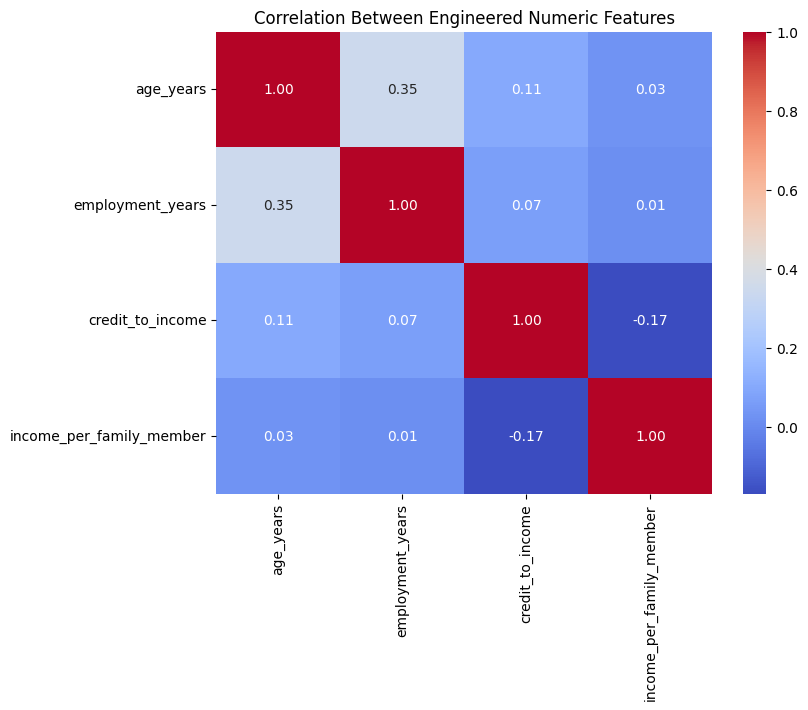

In [50]:
# Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    eda_df[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Engineered Numeric Features")
plt.show()

# EDA Conclusions

## Target

- `default` is imbalanced, with approximately 8.3% positive cases after restricting the dataset to cash loans.

## Data quality

- `DAYS_EMPLOYED` contains the sentinel value `365243`, which is treated as missing before deriving employment duration.
- `OCCUPATION_TYPE` has substantial missingness, and its missingness is strongly associated with `NAME_INCOME_TYPE`.
- `AMT_INCOME_TOTAL` and the derived income-based features are strongly right-skewed.
- `CNT_FAM_MEMBERS` has a minimum value of 1, so household-size normalization does not require handling zero denominators.

## Feature findings

- `age_years` shows a clear decreasing pattern in observed default rate across age deciles.
- `employment_years` generally shows decreasing observed default rates as employment duration increases.
- `credit_to_income` shows a non-monotonic relationship with default, so its relationship with risk is not adequately described by a simple linear trend.
- `income_per_family_member` shows relatively little variation in observed default rates across deciles and does not exhibit a clear monotonic relationship.
- Categorical features show differences in observed default rates, although estimates for rare categories are less stable because of small sample sizes.
- `FLAG_OWN_CAR` shows a modest difference in observed default rates between ownership groups, while `FLAG_OWN_REALTY` shows little difference.
- `employment_years` and `employed_fraction` were highly correlated (`r ≈ 0.95`); therefore, `employed_fraction` was excluded as redundant.

## Feature-selection considerations

The following features will proceed to model development as candidate predictors:

- `age_years`
- `employment_years`
- `credit_to_income`
- `income_per_family_member`
- `CNT_FAM_MEMBERS`
- `NAME_INCOME_TYPE`
- `OCCUPATION_TYPE`
- `NAME_EDUCATION_TYPE`
- `NAME_FAMILY_STATUS`
- `NAME_HOUSING_TYPE`
- `FLAG_OWN_CAR`
- `FLAG_OWN_REALTY`

The EDA establishes candidate features rather than final model importance. Final feature contribution will be assessed during model development. :::
| Feature | Source | Type | Transformation | EDA finding | Decision |
|---|---|---|---|---|---|
| `age_years` | `DAYS_BIRTH` | Numeric | `-DAYS_BIRTH / 365.25` | Clear decreasing pattern in default rate across age deciles | Keep |
| `employment_years` | `DAYS_EMPLOYED` | Numeric | Convert sentinel `365243` to missing, then convert valid values to years | Default rate generally decreases with longer employment duration | Keep |
| `credit_to_income` | `AMT_CREDIT`, `AMT_INCOME_TOTAL` | Numeric | `AMT_CREDIT / AMT_INCOME_TOTAL` | Non-monotonic relationship with default | Keep |
| `income_per_family_member` | `AMT_INCOME_TOTAL`, `CNT_FAM_MEMBERS` | Numeric | `AMT_INCOME_TOTAL / CNT_FAM_MEMBERS` | No clear monotonic relationship with default | Candidate |
| `CNT_FAM_MEMBERS` | `CNT_FAM_MEMBERS` | Numeric | Use as household-size measure | Minimum value is 1 | Candidate |
| `NAME_INCOME_TYPE` | Raw application field | Categorical | Encode and group rare levels where necessary | Default rates differ across categories | Keep |
| `OCCUPATION_TYPE` | Raw application field | Categorical | Handle missingness and encode/group rare levels | Substantial missingness associated with income type | Keep |
| `NAME_EDUCATION_TYPE` | Raw application field | Categorical | Encode and group rare levels where necessary | Default rates differ across categories | Keep |
| `NAME_FAMILY_STATUS` | Raw application field | Categorical | Encode and group rare levels where necessary | Default rates differ across categories | Keep |
| `NAME_HOUSING_TYPE` | Raw application field | Categorical | Encode and group rare levels where necessary | Default rates differ across categories | Keep |
| `FLAG_OWN_CAR` | Raw application field | Binary | Encode `Y/N` | Modest difference in observed default rates | Candidate |
| `FLAG_OWN_REALTY` | Raw application field | Binary | Encode `Y/N` | Little difference in observed default rates | Candidate |

## Preprocessing decisions

- Convert `DAYS_BIRTH` to positive age in years.
- Convert valid `DAYS_EMPLOYED` values to positive employment duration in years.
- Convert `DAYS_EMPLOYED = 365243` to missing before feature engineering.
- Handle missing `OCCUPATION_TYPE` explicitly.
- Group rare categorical levels where appropriate.
- Handle the strong right skew of income-derived variables during preprocessing.
- Preserve the same feature transformations and preprocessing logic during training and inference.